In [8]:
import phate
import matplotlib.pyplot as plt

import numpy as np

import umap

# import sys 
# sys.path.append("..")  # to import from parent directory
from utils.utils import viz_tree

In [2]:

%load_ext autoreload
%autoreload 2

# Handmade way of generating artificial tree

The artificial tree data shown in Fig. [1b](https://www.nature.com/articles/s41587-019-0336-3#Fig1) was constructed as follows. The first branch consists of 100 linearly spaced points that progress in the first four dimensions. 

All other dimensions were set to zero. The 100 points in the second branch are constant in the first four dimensions with a constant value equal to the end point of the first branch. 

The next four dimensions then progress linearly in this branch while all other dimensions were set to zero. The third branch was constructed similarly except the progression occurs in dimensions 9–12 instead of dimensions 5–8. All remaining branches were constructed similarly with some variation in the length of the branches. 

We then added 40 points at each end point and branch point and added zero mean Gaussian noise with a s.d. of 7. This construction models a system where progression along a branch corresponds to an increase in gene expression in several genes. Before adding noise, we also constructed a small gap between the first branch point and the orange branch that splits into a blue and purple branch (see the top set of branches in the left part of Fig. [1b](https://www.nature.com/articles/s41587-019-0336-3#Fig1)). This simulates gaps that are often present in measured biological data. We also added additional noise dimensions, bringing the total dimensionality of the data to 60.

(from the paper)

In [18]:
from datasets import gen_tree

# pick a random direction, place n points in that direction

# from datasets import gen_tree
# def gen_tree(n_dim_per_branch = 4, n_branch=20, branch_length=100, seed=37, sigma=4, merged_branch = False) : 
    
#     # here inside the function, i set the length of the branches. this affects the relative impact of sigma. this value may be too small

#     norm = 100 # length i.e. euclidean norm of the branches 
#     end_point = np.zeros((1,n_dim_per_branch * n_branch))
    
#     T = None
    
 
#     for i in range(n_branch):
        
#         # at the last branch, set the direction to be the same as the previous one. i.e. do not update the direction      
        
#         if not merged_branch or i < n_branch-1 :  
#             direction = np.random.rand(n_dim_per_branch) # random vector indictating a direction
#             direction = direction/np.sum(direction**2) # make it a unit vector
#         else:
#             print("last branch, keeping previous direction")
#             # set i as i-1 so that twe use the same coordinates
#             i = i-1
        
#         points_along_line = np.random.rand(branch_length) * norm # could also do a random uniform sampling along that direction
        
#         new_branch = np.zeros((branch_length, n_dim_per_branch * n_branch)) # points in branch x dims
#         new_branch_few_dim = np.outer(points_along_line, direction) # in only n_dim_per_branch dimensions
        
#         # pad with zeros and add the previous endpoint
#         new_branch[:, i*n_dim_per_branch: (i+1)*n_dim_per_branch ] =  new_branch_few_dim
#         new_branch = new_branch + end_point
        

#         if T is None:
#             T = new_branch
#             idx_max = np.argmax(points_along_line)
#             end_point = new_branch[idx_max,:] # set the last point of the first branch as endpoint.
#         else:
#             T = np.concatenate([T, new_branch])        

#     noise = np.random.normal(0, sigma, T.shape)
#     T = T + noise

        
#     # returns the branch labels for each point to make it easier to visualize
#     # embeddings
#     C = np.array([i // branch_length for i in range(n_branch * branch_length)])

#     return T, C


Calculating PHATE...
  Running PHATE on 900 observations and 27 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.21 seconds.
    Calculating affinities...
    Calculated affinities in 0.03 seconds.
  Calculated graph and diffusion operator in 0.25 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.52 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.59 seconds.
Calculated PHATE in 2.38 seconds.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


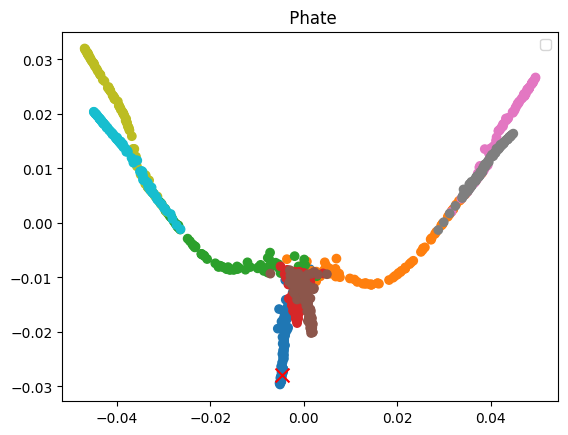

In [31]:
tree, branches, idx_root = gen_tree(n_branch=9, n_child = [4,2,2], n_dim_per_branch = 3, branch_length=100, sigma=10, seed = 5, merged_branch = False)

op, tree = viz_tree(tree, branches, idx_root, methods=["PHATE"], phate_t = 25, phate_knn = 20)

# example

In [ ]:
# modality 1
tree1, branches1 = gen_tree(n_dim_per_branch = 5, n_branch=5, branch_length=100, sigma=0, seed = 3, merged_branch = False)
tree2, branches2 = gen_tree(n_dim_per_branch = 5, n_branch=5, branch_length=100, sigma=0, seed = 3, merged_branch = True)

viz_tree(tree1, branches1, phate_t = 25, phate_knn = 20, methods=["UMAP"], title="modality 1")
viz_tree(tree2, branches2, phate_t = 25, phate_knn = 20, methods=["UMAP"], title="modality 2")

# function from PHATE 
Generate in 2D

In [ ]:
# without noise

tree, branches = phate.tree.gen_dla(n_dim = 2, n_branch = 4, branch_length = 100, 
                                            rand_multiplier = 3, seed=37, sigma = 0)

plt.figure()
plt.scatter(tree[:,0], tree[:,1], c=branches)

In [ ]:
# generate in 2d and visualize. check the impact of some parameters, sigma for noise and rand_multiplier which is not explained

sigmas = [0, 2]
rand_multipliers = [1,1.5,1.8, 2, 2.8, 2.5, 3, 5]


# sigmas = [5,3]
# rand_multipliers = [1, 2]

dim = 3

fig = plt.figure(figsize= (20,20))


# add first empty plot in corner: 
ax = fig.add_subplot(len(sigmas)+1, len(rand_multipliers)+1, 1)
ax.axis('off')

i = 2
# add the first row for labels: 

for rand_multiplier in rand_multipliers:

    ax = fig.add_subplot(len(sigmas)+1, len(rand_multipliers)+1, i)
    ax.text(0.1, 0.85, f"rand_multiplier = {rand_multiplier}", verticalalignment='bottom') 
    ax.axis('off')
    i = i+1
    
# ax.text(0.1, 0.85,f"sigma = {sigma}")


for sigma in sigmas:
       

    ax = fig.add_subplot(len(sigmas)+1, len(rand_multipliers)+1, i)
    ax.text(0.1, 0.85,f"sigma = {sigma}", horizontalalignment='right')
    ax.axis('off')

    i=i+1
    
    for rand_multiplier in rand_multipliers:
        tree, branches = phate.tree.gen_dla(n_dim = dim, n_branch = 4, branch_length = 50, 
                                            rand_multiplier = rand_multiplier, seed=37, sigma = sigma)
    
        if dim == 3:
            ax=fig.add_subplot(len(sigmas)+1, len(rand_multipliers)+1, i, projection='3d')
            ax.scatter(tree[:,0], tree[:,1], tree[:,2], c=branches)
            
        if dim == 2:
            ax=fig.add_subplot(len(sigmas)+1, len(rand_multipliers)+1, i)
            ax.scatter(tree[:,0], tree[:,1], c=branches)
            
            
#         ax.set_title((f"sigma = {sigma} \n rand_mutliplier = {rand_multiplier}"))
        i = i +1
        
plt.show()        
plt.close()

# with DLA in high dimensions


In [ ]:
tree, branches = phate.tree.gen_dla(n_dim = 200, n_branch = 5, branch_length = 300, 
                                    rand_multiplier = 2, seed=37, sigma = 5)

viz_tree(tree,branches)

In [ ]:
# modify the data to have one branch mixing 

def gen_dla(n_dim=100, n_branch=20, branch_length=100, rand_multiplier=2, seed=37, sigma=4, merged_branch = True):
    if merged_branch:
        n_branch = n_branch - 1 # because the last one will be double
        print(n_branch)
    
    np.random.seed(seed)
    M = np.cumsum(rand_multiplier *  ( -1 + 2*np.random.rand(branch_length, n_dim))  , 0)    
    C_last_branch=np.array([])
    
    for i in range(n_branch):
        rng = np.random.default_rng()
        ind = rng.integers(branch_length)
        
        # new branch direction
        -1 + 2* np.random.rand(1, n_dim)
        
        if (not merged_branch) or i < n_branch - 1 :
            A = rand_multiplier * (-1 + 2*np.random.rand(branch_length, n_dim))
           
        else: # if merged branch, at the last branch put twice as many points
            print("merging last branch")
            
            A = rand_multiplier * (-1 + 2*np.random.rand(2*branch_length, n_dim))
            # randomly assign labels within this last branch. with equal numbers
            C_last_branch = np.concatenate((n_branch * np.ones(branch_length), (n_branch+1) * np.ones(branch_length)))
            C_last_branch = rng.permutation(C_last_branch)

        
        new_branch = np.cumsum(A, 0)
        M = np.concatenate([M, new_branch + M[ind, :]])
        
    noise = np.random.normal(0, sigma, M.shape)
    M = M + noise

    
    # returns the group labels for each point to make it easier to visualize
    # embeddings
    C = np.array([i // branch_length for i in range(n_branch * branch_length)])   
    C = np.concatenate((C, C_last_branch))
       
    return M, C



tree, branches = gen_dla(n_dim = 2, n_branch = 4, branch_length = 100, rand_multiplier = 1, seed=37, sigma = 0)

plt.figure()
plt.scatter(tree[:,0], tree[:,1], c = branches)

In [ ]:
tree, branches = gen_dla(n_dim = 200, n_branch = 5, branch_length = 300, 
                                    rand_multiplier = 2, seed=37, sigma = 5, merged_branch = True)

viz_tree(tree,branches)